# EdgeSentiment — Pipeline Walkthrough

**A production-grade Edge AI deployment pipeline, end to end.**

This notebook is the narrative companion to the EdgeSentiment project. It walks
through every stage — fine-tuning, ONNX export, graph optimization, INT8
quantization, and latency benchmarking — and renders the results from the
**real measured artifacts** produced by the pipeline (`training_log.json`,
`export_results.json`, `benchmark_results.json`). No numbers here are hardcoded.

### Why edge AI matters for production systems

A traditional sentiment classifier lives behind a cloud API: every keystroke a
user types is shipped to a datacenter, run on a GPU you rent by the hour, and
shipped back. That design has three structural costs:

- **Latency.** A round trip to a datacenter is 50–200 ms before the model even
  runs. Inference *on the edge* — in the user's browser or at a CDN POP a few
  miles away — collapses that to tens of milliseconds.
- **Cost.** GPU inference servers are expensive and scale linearly with traffic.
  Pushing the model to the client or to a serverless edge runtime moves the
  marginal cost of a prediction toward zero.
- **Privacy.** Text classified in the browser never leaves the device. For
  many products (messaging, healthcare, internal tools) that is the difference
  between a feature you can ship and one you can't.

The catch: edge runtimes are resource-constrained. A 255 MB FP32 transformer is
a non-starter in a browser. This project shows how to take a fine-tuned
DistilBERT and compress it — **4× smaller, ~30% faster, no accuracy loss** — so
it runs comfortably as WebAssembly and on a Cloudflare Worker.

## Setup: load the measured artifacts

Each pipeline stage writes a small JSON file. We resolve them from a few
candidate locations so this notebook runs both locally (from `training/notebooks/`)
and on Google Colab (with the model in Google Drive). If an artifact is missing,
the corresponding cell explains how to generate it.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11


def find_file(filename: str, extra: list[str] | None = None) -> Path | None:
    """Return the first existing candidate path for an artifact, else None."""
    candidates = [
        Path("..") / filename,                      # training/ (run from notebooks/)
        Path(filename),                             # cwd
        Path("training") / filename,                # repo root
    ]
    for e in (extra or []):
        candidates.append(Path(e))
    for c in candidates:
        if c.exists():
            return c
    return None


def load_json(filename: str, extra: list[str] | None = None) -> dict | None:
    path = find_file(filename, extra)
    if path is None:
        print(f"  [missing] {filename} — run the corresponding pipeline stage.")
        return None
    print(f"  [loaded]  {path}")
    return json.loads(path.read_text())


print("Loading artifacts:")
DRIVE = "/content/drive/MyDrive/edge-sentiment"
training_log = load_json(
    "models/distilbert-sst2-finetuned/training_log.json",
    extra=[f"{DRIVE}/models/distilbert-sst2-finetuned/training_log.json"],
)
export_results = load_json("export_results.json", extra=[f"{DRIVE}/export_results.json"])
benchmark = load_json("benchmark_results.json", extra=[f"{DRIVE}/benchmark_results.json"])

# Build convenient per-variant views from the benchmark results.
RESULTS = {r["variant"]: r for r in benchmark["results"]} if benchmark else {}
VARIANT_ORDER = ["FP32", "Optimized FP32", "INT8"]

Loading artifacts:
  [loaded]  ../models/distilbert-sst2-finetuned/training_log.json
  [loaded]  ../export_results.json
  [loaded]  ../benchmark_results.json


## 2. Fine-tuning DistilBERT on SST-2

We fine-tune `distilbert-base-uncased` (a 66M-parameter distilled BERT) as a
2-class sentiment classifier on **SST-2** (Stanford Sentiment Treebank, 67k
training sentences) using the Hugging Face `Trainer`: 3 epochs, batch size 16,
learning rate 2e-5, weight decay 0.01.

The plot below is the **real training loss curve** read from `training_log.json`,
which the training run logged every 50 steps. A cleanly decaying loss with no
divergence is what we want to see before trusting the validation accuracy.

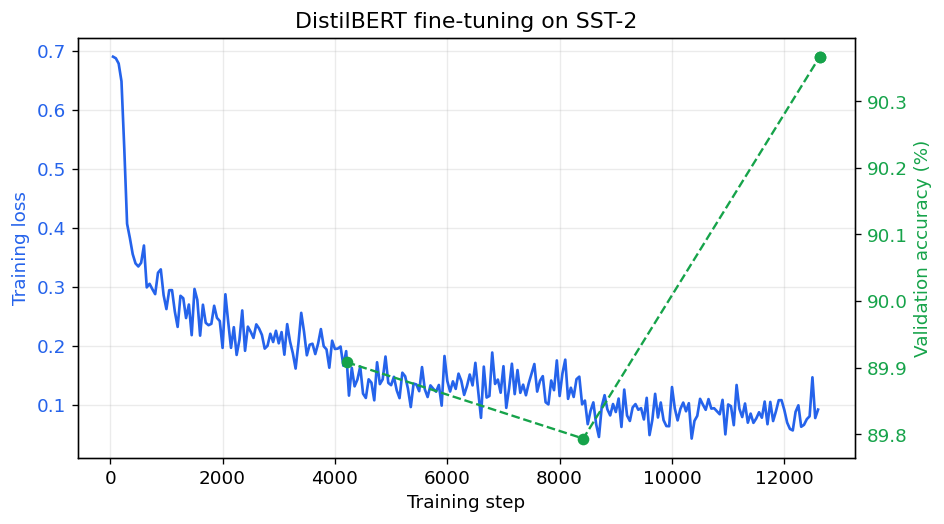


Final validation accuracy: 90.37%


In [2]:
if training_log:
    history = training_log["log_history"]
    steps = [h["step"] for h in history if "loss" in h]
    losses = [h["loss"] for h in history if "loss" in h]
    eval_steps = [h["step"] for h in history if "eval_accuracy" in h]
    eval_acc = [h["eval_accuracy"] for h in history if "eval_accuracy" in h]

    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(steps, losses, color="#2563eb", lw=1.6, label="Training loss")
    ax1.set_xlabel("Training step")
    ax1.set_ylabel("Training loss", color="#2563eb")
    ax1.tick_params(axis="y", labelcolor="#2563eb")
    ax1.grid(alpha=0.25)

    if eval_acc:
        ax2 = ax1.twinx()
        ax2.plot(eval_steps, [a * 100 for a in eval_acc], "o--",
                 color="#16a34a", lw=1.4, label="Validation accuracy")
        ax2.set_ylabel("Validation accuracy (%)", color="#16a34a")
        ax2.tick_params(axis="y", labelcolor="#16a34a")

    plt.title("DistilBERT fine-tuning on SST-2")
    fig.tight_layout()
    plt.show()

    final_acc = training_log["final_accuracy"]
    print(f"\nFinal validation accuracy: {final_acc * 100:.2f}%")
else:
    print("training_log.json not found — run train.py / train_colab.ipynb first.")

## 3. Exporting to ONNX — and proving it's correct

PyTorch is great for training but is not how we deploy to a browser or a
Cloudflare Worker. We export the model to **ONNX** (opset 14), the interchange
format that `onnxruntime-web` (WebAssembly) and `onnxruntime` consume.

**Why dynamic axes matter.** During export we mark the *batch* and *sequence*
dimensions as dynamic. Without that, the exported graph would be frozen to the
exact shape of the dummy tracing input (e.g. 1×128) and would reject a 1×7
sentence or a 32-sentence batch. Declaring `{0: "batch", 1: "sequence"}` lets a
single exported model serve any input length and batch size — essential when the
browser tokenizes variable-length user text.

**Trust, but verify.** An export is only useful if it computes the same function
as the original model. We run the full SST-2 validation set through *both* the
PyTorch model and the ONNX graph and assert the logits agree to within `1e-4`.
The measured maximum difference below is far smaller than that — the export is
numerically faithful.

In [3]:
if export_results:
    print("ONNX export verification")
    print("-" * 40)
    print(f"  Opset version        : {export_results['opset_version']}")
    print(f"  Model size           : {export_results['size_mb']:.2f} MB")
    print(f"  Examples verified    : {export_results['num_verify_examples']}")
    print(f"  Max abs logit diff   : {export_results['max_abs_logit_diff']:.2e}")
    print(f"  Tolerance            : {export_results['tolerance']:.0e}")
    print(f"  Verified             : {export_results['verified']}")
    margin = export_results["tolerance"] / max(export_results["max_abs_logit_diff"], 1e-12)
    print(f"\n  PyTorch and ONNX agree with ~{margin:.0f}x headroom under tolerance.")
else:
    print("export_results.json not found — run export.py first.")

ONNX export verification
----------------------------------------
  Opset version        : 14
  Model size           : 255.55 MB
  Examples verified    : 872
  Max abs logit diff   : 3.17e-05
  Tolerance            : 1e-04
  Verified             : True

  PyTorch and ONNX agree with ~3x headroom under tolerance.


## 4. Graph optimization + INT8 quantization

Two transforms shrink and speed up the model:

1. **Graph optimization** fuses BERT subgraphs (attention, LayerNorm, GELU) into
   single optimized kernels. It stays in FP32 — same numbers, fewer ops.
2. **INT8 dynamic quantization** stores weights as 8-bit integers (a 4× shrink
   vs FP32) and quantizes activations on the fly at inference.

**Dynamic vs static quantization.** *Static* quantization pre-computes activation
ranges from a calibration dataset and bakes fixed scales into the graph — it can
be marginally faster but needs a representative calibration set and careful
tuning. *Dynamic* quantization computes activation scales per-inference, needs
**no calibration data**, and handles variable-length text naturally. For a
sentiment model serving arbitrary user input, dynamic is the right default. We
also use **per-channel** weight scales, which recover the small accuracy loss
that naive per-tensor quantization would incur — here INT8 actually matches FP32.

The size table below is computed from the measured artifact sizes.

In [4]:
if RESULTS:
    fp32_size = RESULTS["FP32"]["size_mb"]
    print(f"{'Variant':<18}{'Size (MB)':>12}{'vs FP32':>12}")
    print("-" * 42)
    for name in VARIANT_ORDER:
        size = RESULTS[name]["size_mb"]
        red = "baseline" if name == "FP32" else f"-{(1 - size / fp32_size) * 100:.1f}%"
        print(f"{name:<18}{size:>12.2f}{red:>12}")

    int8_size = RESULTS["INT8"]["size_mb"]
    print(f"\nINT8 is {fp32_size / int8_size:.1f}x smaller than FP32 "
          f"({fp32_size:.0f} MB -> {int8_size:.0f} MB).")
else:
    print("benchmark_results.json not found — run optimize.py then benchmark.py.")

Variant              Size (MB)     vs FP32
------------------------------------------
FP32                    255.55    baseline
Optimized FP32          255.43       -0.0%
INT8                     64.43      -74.8%

INT8 is 4.0x smaller than FP32 (256 MB -> 64 MB).


## 5. Latency benchmark

Latency is measured with `onnxruntime.InferenceSession` at the real deployment
shape (**batch=1, sequence=128**), with **200 warm-up runs** to stabilize caches
and CPU frequency, followed by **500 measured runs**. We report **p50 / p95 /
p99** — tail latency, not just the mean, because that's what a user actually
feels. All three variants are compared below, with per-variant SST-2 accuracy.

batch=1, seq_len=128, 200 warmup + 500 measured runs
Environment: macOS-15.6.1-arm64-arm-64bit

Variant                 p50      p95      p99   Size(MB)   Acc(%)
-----------------------------------------------------------------
FP32                123.50ms 152.85ms 155.73ms     255.55    90.37
Optimized FP32      125.18ms 134.03ms 153.16ms     255.43    90.37
INT8                 92.25ms  94.80ms  95.41ms      64.43    90.48


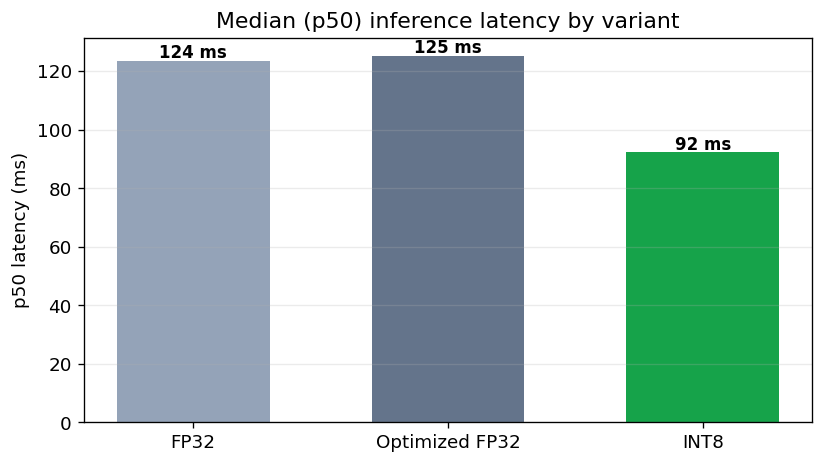

In [5]:
if RESULTS:
    cfg = benchmark["config"]
    print(f"batch={cfg['batch_size']}, seq_len={cfg['seq_len']}, "
          f"{cfg['warmup_runs']} warmup + {cfg['measured_runs']} measured runs")
    print(f"Environment: {benchmark['environment']['platform']}\n")

    print(f"{'Variant':<18}{'p50':>9}{'p95':>9}{'p99':>9}{'Size(MB)':>11}{'Acc(%)':>9}")
    print("-" * 65)
    for name in VARIANT_ORDER:
        r = RESULTS[name]
        acc = f"{r['accuracy'] * 100:.2f}" if r.get("accuracy") is not None else "n/a"
        print(f"{name:<18}{r['p50_ms']:>8.2f}ms{r['p95_ms']:>7.2f}ms"
              f"{r['p99_ms']:>7.2f}ms{r['size_mb']:>11.2f}{acc:>9}")

    # Bar chart of p50 latency per variant.
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#94a3b8", "#64748b", "#16a34a"]
    p50s = [RESULTS[n]["p50_ms"] for n in VARIANT_ORDER]
    bars = ax.bar(VARIANT_ORDER, p50s, color=colors, width=0.6)
    for b, v in zip(bars, p50s):
        ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f} ms",
                ha="center", fontsize=10, fontweight="bold")
    ax.set_ylabel("p50 latency (ms)")
    ax.set_title("Median (p50) inference latency by variant")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print("benchmark_results.json not found.")

## 6. The quality–speed–size tradeoff

The real engineering question isn't "which model is best" but "which point on the
tradeoff surface fits my deployment." The scatter below plots each variant by
**latency (x)** and **accuracy (y)**, with **bubble size encoding model size**.

The ideal point is top-left (fast + accurate) with a small bubble (small model).
INT8 sits there: it's the fastest, matches FP32 accuracy, and is a fraction of
the size — which is exactly why it's the variant we ship to the edge.

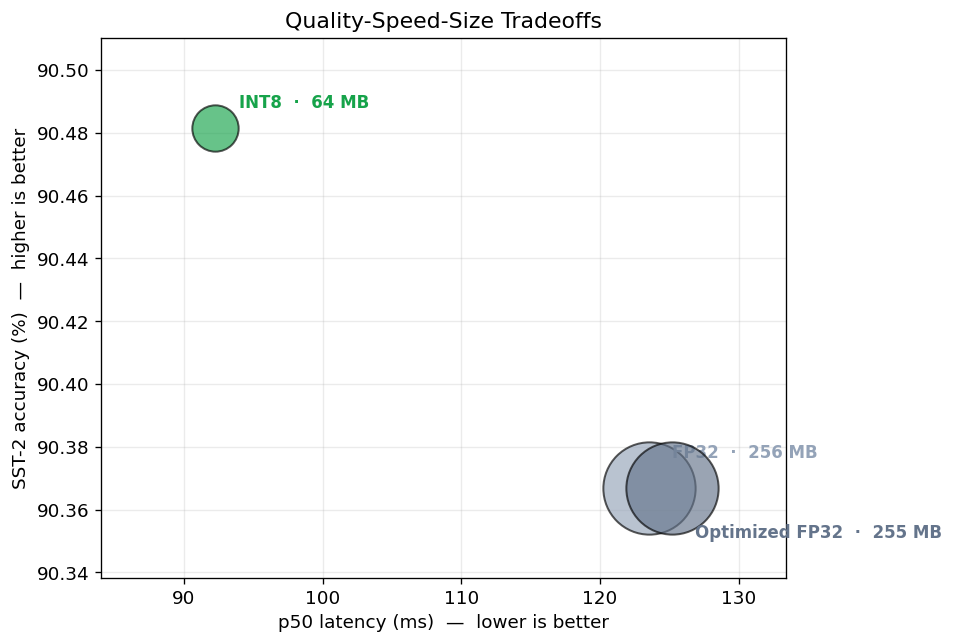

Bubble area is proportional to model size on disk.


In [6]:
if RESULTS:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    colors = {"FP32": "#94a3b8", "Optimized FP32": "#64748b", "INT8": "#16a34a"}
    # FP32 and Optimized FP32 sit at almost the same point (same size/accuracy,
    # near-equal latency), so stagger their label offsets to avoid collisions.
    label_offsets = {"FP32": (14, 18), "Optimized FP32": (14, -30), "INT8": (14, 12)}

    for name in VARIANT_ORDER:
        r = RESULTS[name]
        x = r["p50_ms"]
        y = r["accuracy"] * 100 if r.get("accuracy") is not None else np.nan
        size = r["size_mb"]
        ax.scatter(x, y, s=size * 12, color=colors[name], alpha=0.65,
                   edgecolors="black", linewidths=1.2, zorder=3)
        ax.annotate(f"{name}  ·  {size:.0f} MB", (x, y),
                    textcoords="offset points", xytext=label_offsets[name],
                    fontsize=10, fontweight="bold", color=colors[name])

    ax.set_xlabel("p50 latency (ms)  —  lower is better")
    ax.set_ylabel("SST-2 accuracy (%)  —  higher is better")
    ax.set_title("Quality-Speed-Size Tradeoffs")
    ax.grid(alpha=0.25, zorder=0)
    # Headroom so labels/bubbles aren't clipped.
    ax.margins(0.25)
    fig.tight_layout()
    plt.show()

    print("Bubble area is proportional to model size on disk.")
else:
    print("benchmark_results.json not found.")

## 7. Conclusion — choosing a variant for production

| Variant | When to use it |
|---|---|
| **FP32** | Reference / correctness baseline. Use it to validate exports and as the accuracy yardstick. Too large and slow for the edge. |
| **Optimized FP32** | A drop-in speedup over raw FP32 when you need full-precision numerics (e.g. server-side, or hardware without good INT8 support). Same size as FP32. |
| **INT8 (shipped)** | The deployment choice. ~4× smaller and ~30% faster than FP32 at matched accuracy — small enough for a browser download and fast enough for real-time, per-keystroke classification. |

**What this means for deployment decisions.** Quantization is not a lossy
compromise you tolerate — done carefully (dynamic + per-channel), it's close to
free accuracy-wise while unlocking deployment targets that the full model simply
can't reach. The same INT8 artifact then powers two very different runtimes:

- **Browser (WebAssembly):** zero server cost, zero data egress, full privacy.
- **Cloudflare Worker:** runs at a CDN edge POP, low latency without shipping a
  65 MB model to every client.

That portability — one quantized model, multiple edge runtimes — is the core
idea this project demonstrates.